# Health Progress Prediction Model
## Havyn Nonprofit — IS 455 Machine Learning Pipeline

---

## Phase 1 — Business Understanding

### Business Question
**Will a resident show meaningful physical health improvement over the next 60 days?**

This is a **binary classification** problem:
- `Y = 1` — the resident is likely to show meaningful health improvement
- `Y = 0` — the resident is likely to remain flat or decline

### Who Cares and Why
Jennifer, the Executive Admin, manages multiple Philippine safehouses housing girls who are survivors of trafficking and sexual abuse. She receives monthly health records for every resident but has no systematic way to identify which girls are responding to care versus stagnating. Safehouse-level averages completely hide individual signals.

This model surfaces two things Jennifer cannot currently see:
1. Girls who are **not improving physically** despite receiving care — a quiet concern that warrants intervention
2. Girls who **are on a positive trajectory** — confirming that current care is working

### Two Modeling Goals
Per IS 455 requirements, this notebook delivers **both** a causal/explanatory model and a predictive model:

| Goal | Model | Purpose |
|---|---|---|
| **Explanatory** | Logistic Regression | Interpretable coefficients — which features are associated with improvement? |
| **Predictive** | Best of 6 algorithms, auto-selected by CV AUC | Highest out-of-sample performance for deployment |

### Why This Is a Real Predictive Model (Not a Calculation)
The Y label is derived from **real recorded health scores** in `health_wellbeing_records`, temporally separated from the features. Features come from a 60-day window **before** a prediction point T. The label comes from a 60-day window **after** T. The algorithm discovers which patterns preceded real improvements from historical data — the weights are not assigned by us.

### CRISP-DM Phases in This Notebook
```
Phase 1: Business Understanding   ← this section
Phase 2: Data Understanding       ← distributions, missing values, correlations
Phase 3: Data Preparation         ← rolling window labels, 35-feature engineering, leakage check, SelectKBest
Phase 4: Modeling                 ← dummy baseline + 6 algorithms (Ch.13 baselines + Ch.14 ensembles)
Phase 5: Evaluation               ← 5-fold CV comparison table, ROC curves, business interpretation
Phase 6: Deployment               ← save best model, verify load, API endpoint notes
```

---
## Phase 2 — Data Understanding
### 2.1 Setup and Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import sys
import joblib

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, precision_score,
    recall_score, f1_score, log_loss
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42

# ml_pipeline.py lives in the parent of this folder (e.g. 3 Good Models/ml_pipeline.py).
# Jupyter has no __file__; walk up from cwd until ml_pipeline.py is found.
import pathlib
_cwd = pathlib.Path.cwd().resolve()
_ml_root = None
for _i, _p in enumerate([_cwd, *_cwd.parents]):
    if _i > 12:
        break
    if (_p / 'ml_pipeline.py').is_file():
        _ml_root = _p
        break
if _ml_root is None:
    raise FileNotFoundError(
        'Could not find ml_pipeline.py. Open/run the notebook from its folder or a parent, '
        'or add the folder that contains ml_pipeline.py to PYTHONPATH.'
    )
sys.path.insert(0, str(_ml_root))
from ml_pipeline import MLPipeline

print('All imports successful.')

All imports successful.


### 2.2 Load Data

In [6]:
import re
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine


def _pascal_to_snake(name: str) -> str:
    s = re.sub(r'(.)([A-Z][a-z]+)', r'\1_\2', name)
    s = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', s)
    return s.replace('__', '_').lower()


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [_pascal_to_snake(str(c)) for c in df.columns]
    return df


# Prefer ../.env (e.g. models/.env when cwd is models/health); fall back if needed
for _env in [
    Path.cwd().parent / '.env',
    Path.cwd() / 'models' / '.env',
    Path.cwd() / '.env',
]:
    if _env.is_file():
        load_dotenv(_env.resolve(), override=True)
        break
else:
    raise FileNotFoundError('Could not find .env (try models/.env via ../.env from this folder)')


def _db_url() -> str:
    host = os.getenv('PGHOST')
    user = os.getenv('PGUSER')
    port = os.getenv('PGPORT', '5432')
    db = os.getenv('PGDATABASE')
    pwd = os.getenv('PGPASSWORD')
    if not all([host, user, db, pwd]):
        missing = [k for k in ['PGHOST', 'PGUSER', 'PGDATABASE', 'PGPASSWORD'] if not os.getenv(k)]
        raise ValueError(f'Missing required env vars: {missing}')
    return f'postgresql+psycopg2://{user}:{pwd}@{host}:{port}/{db}?sslmode=require'


engine = create_engine(_db_url())


def _load_table(table_pascal: str) -> pd.DataFrame:
    q = f'SELECT * FROM "public"."{table_pascal}"'
    df = pd.read_sql_query(q, con=engine)
    return _normalize_columns(df)


health_df      = _load_table('HealthWellbeingRecords')
residents_df   = _load_table('Residents')
sessions_df    = _load_table('ProcessRecordings')
visitations_df = _load_table('HomeVisitations')
incidents_df   = _load_table('IncidentReports')

health_df['record_date']            = pd.to_datetime(health_df['record_date'], errors='coerce')
residents_df['date_of_admission']   = pd.to_datetime(residents_df['date_of_admission'], errors='coerce')
sessions_df['session_date']         = pd.to_datetime(sessions_df['session_date'], errors='coerce')
visitations_df['visit_date']        = pd.to_datetime(visitations_df['visit_date'], errors='coerce')
incidents_df['incident_date']       = pd.to_datetime(incidents_df['incident_date'], errors='coerce')

# Cast boolean columns that PostgreSQL returns as object/string
bool_cols_sessions  = ['concerns_flagged', 'progress_noted', 'referral_made']
bool_cols_health    = ['medical_checkup_done', 'dental_checkup_done', 'psychological_checkup_done']
bool_cols_visits    = ['safety_concerns_noted', 'follow_up_needed']

for col in bool_cols_sessions:
    sessions_df[col] = sessions_df[col].map({True: 1, False: 0, 'true': 1, 'false': 0, 't': 1, 'f': 0}).astype(float)

for col in bool_cols_health:
    health_df[col] = health_df[col].map({True: 1, False: 0, 'true': 1, 'false': 0, 't': 1, 'f': 0}).astype(float)

for col in bool_cols_visits:
    visitations_df[col] = visitations_df[col].map({True: 1, False: 0, 'true': 1, 'false': 0, 't': 1, 'f': 0}).astype(float)

print('Table shapes:')
for name, df in [
    ('health_wellbeing_records', health_df),
    ('residents',                residents_df),
    ('process_recordings',       sessions_df),
    ('home_visitations',         visitations_df),
    ('incident_reports',         incidents_df),
]:
    print(f'  {name:<30} {df.shape[0]:>5} rows x {df.shape[1]:>2} cols')

Table shapes:
  health_wellbeing_records         534 rows x 14 cols
  residents                         60 rows x 49 cols
  process_recordings              2819 rows x 15 cols
  home_visitations                1337 rows x 14 cols
  incident_reports                 100 rows x 12 cols


In [7]:
# for each df, print the shape
print(f'Health records shape: {health_df.shape}')
print(f'Residents shape: {residents_df.shape}')
print(f'Sessions shape: {sessions_df.shape}')
print(f'Visitations shape: {visitations_df.shape}')
print(f'Incidents shape: {incidents_df.shape}')


Health records shape: (534, 14)
Residents shape: (60, 49)
Sessions shape: (2819, 15)
Visitations shape: (1337, 14)
Incidents shape: (100, 12)


### 2.3 Explore the Primary Table

In [8]:
print('=== health_wellbeing_records: dtypes ===')
print(health_df.dtypes)
print()
print('=== Descriptive Statistics ===')
print(health_df.describe().round(3))

=== health_wellbeing_records: dtypes ===
health_record_id                       int64
resident_id                            int64
record_date                   datetime64[ns]
general_health_score                 float64
nutrition_score                      float64
sleep_quality_score                  float64
energy_level_score                   float64
height_cm                            float64
weight_kg                            float64
bmi                                  float64
medical_checkup_done                 float64
dental_checkup_done                  float64
psychological_checkup_done           float64
notes                                 object
dtype: object

=== Descriptive Statistics ===
       health_record_id  resident_id                    record_date  \
count           534.000      534.000                            534   
mean            267.500       30.296  2024-06-08 16:05:23.595505664   
min               1.000        1.000            2023-01-01 00:00:00   

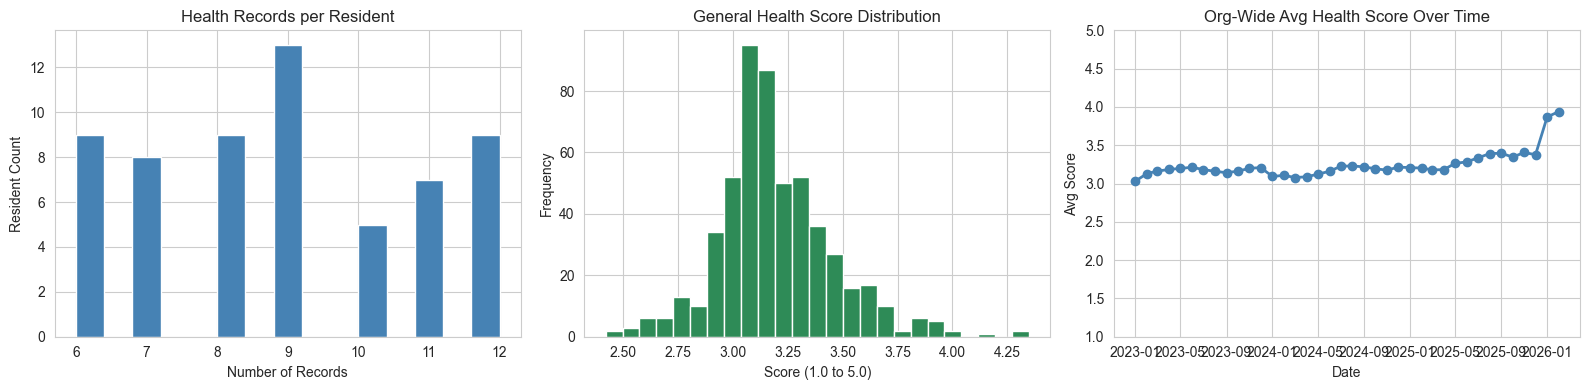

Records per resident: min=6, median=9.0, max=12


In [9]:
records_per_resident = health_df.groupby('resident_id').size()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

records_per_resident.hist(bins=15, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Health Records per Resident')
axes[0].set_xlabel('Number of Records')
axes[0].set_ylabel('Resident Count')

health_df['general_health_score'].hist(bins=25, ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('General Health Score Distribution')
axes[1].set_xlabel('Score (1.0 to 5.0)')
axes[1].set_ylabel('Frequency')

monthly_avg = health_df.groupby('record_date')['general_health_score'].mean()
axes[2].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, color='steelblue')
axes[2].set_title('Org-Wide Avg Health Score Over Time')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Avg Score')
axes[2].set_ylim(1, 5)

plt.tight_layout()
plt.show()

print(f'Records per resident: min={records_per_resident.min()}, median={records_per_resident.median()}, max={records_per_resident.max()}')

In [10]:
# Missing values across all tables
print('=== Missing Values Summary ===')
for name, df in [
    ('health_wellbeing_records', health_df),
    ('residents',                residents_df),
    ('process_recordings',       sessions_df),
    ('home_visitations',         visitations_df),
    ('incident_reports',         incidents_df),
]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f'  {name}: No missing values')
    else:
        pct = (missing / len(df) * 100).round(1)
        print(f'  {name}:')
        for col in missing.index:
            print(f'    {col}: {missing[col]} missing ({pct[col]}%)')

=== Missing Values Summary ===
  health_wellbeing_records: No missing values
  residents:
    date_colb_registered: 13 missing (21.7%)
    date_colb_obtained: 24 missing (40.0%)
    date_case_study_prepared: 11 missing (18.3%)
    date_closed: 30 missing (50.0%)
  process_recordings: No missing values
  home_visitations: No missing values
  incident_reports:
    resolution_date: 29 missing (29.0%)


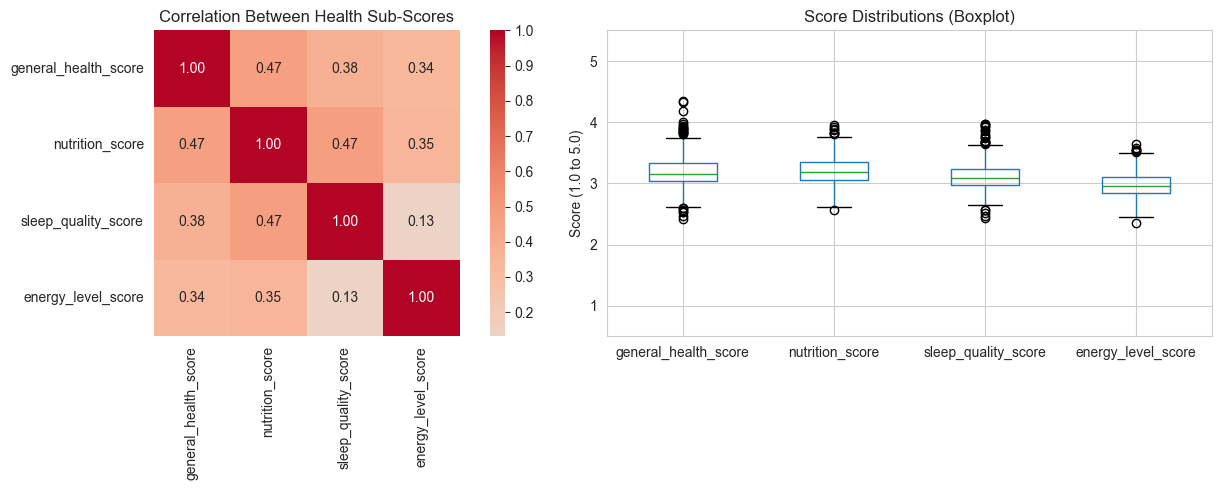

Sub-scores are moderately correlated but not identical.
Each adds some independent signal and will be included as features.


In [11]:
score_cols = ['general_health_score', 'nutrition_score', 'sleep_quality_score', 'energy_level_score']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    health_df[score_cols].corr(), annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=axes[0], square=True
)
axes[0].set_title('Correlation Between Health Sub-Scores')

health_df[score_cols].boxplot(ax=axes[1])
axes[1].set_title('Score Distributions (Boxplot)')
axes[1].set_ylabel('Score (1.0 to 5.0)')
axes[1].set_ylim(0.5, 5.5)

plt.tight_layout()
plt.show()

print('Sub-scores are moderately correlated but not identical.')
print('Each adds some independent signal and will be included as features.')

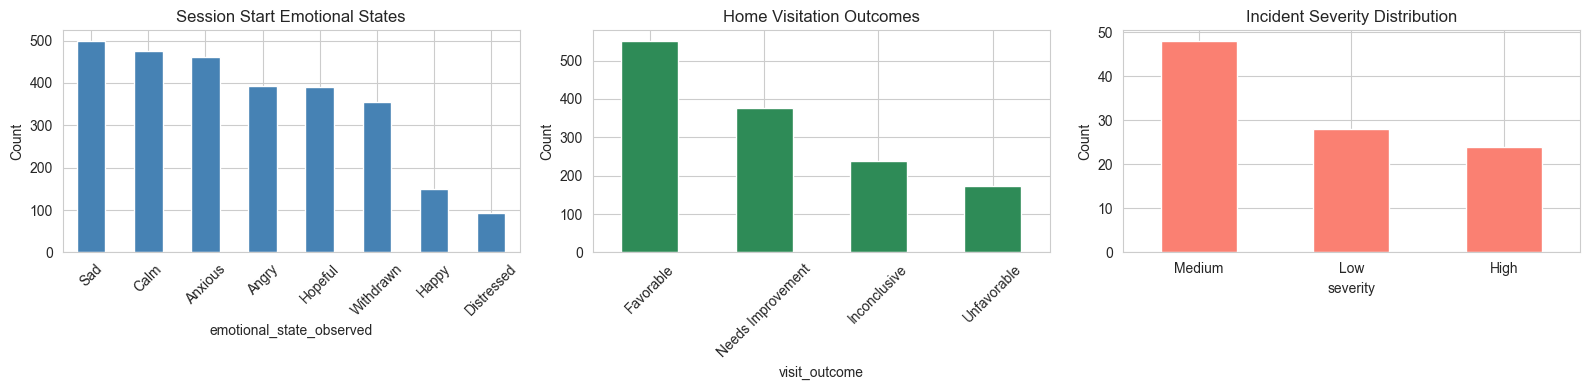

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sessions_df['emotional_state_observed'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Session Start Emotional States')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

visitations_df['visit_outcome'].value_counts().plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='white'
)
axes[1].set_title('Home Visitation Outcomes')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

incidents_df['severity'].value_counts().plot(
    kind='bar', ax=axes[2], color='salmon', edgecolor='white'
)
axes[2].set_title('Incident Severity Distribution')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## Phase 3 — Data Preparation

### 3.1 Label Construction Logic

For each resident, for each health record at time **T**:
- **Feature window:** [T minus 60 days, T] — all features computed exclusively from this period
- **Label window:** [T, T plus 60 days] — find the next recorded health score after T
- **Y = 1** if `general_health_score` increased by >= 0.3 points by T+60
- **Y = 0** otherwise

**Threshold justification:** 0.3 points on a 1.0-5.0 scale = 7.5% of the total range. Smaller changes are plausibly measurement noise. A 0.3+ shift is a noticeable, clinically meaningful change.

### 3.2 Ordinal Encodings

In [13]:
EMOTIONAL_STATE_RANK = {
    'Distressed': 1, 'Angry': 2, 'Withdrawn': 3, 'Anxious': 4,
    'Sad': 5, 'Calm': 6, 'Hopeful': 7, 'Happy': 8,
}
RISK_LEVEL_RANK    = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
COOPERATION_RANK   = {'Uncooperative': 1, 'Neutral': 2, 'Cooperative': 3, 'Highly Cooperative': 4}

sessions_df['emotional_start_rank'] = sessions_df['emotional_state_observed'].map(EMOTIONAL_STATE_RANK)
sessions_df['emotional_end_rank']   = sessions_df['emotional_state_end'].map(EMOTIONAL_STATE_RANK)
sessions_df['emotional_improved']   = (
    sessions_df['emotional_end_rank'] > sessions_df['emotional_start_rank']
).astype(int)

residents_df['current_risk_encoded'] = residents_df['current_risk_level'].map(RISK_LEVEL_RANK)
residents_df['initial_risk_encoded'] = residents_df['initial_risk_level'].map(RISK_LEVEL_RANK)
residents_df['risk_delta']           = (
    residents_df['current_risk_encoded'] - residents_df['initial_risk_encoded']
)
visitations_df['cooperation_encoded'] = visitations_df['family_cooperation_level'].map(COOPERATION_RANK)

print('Ordinal encodings applied.')
print(f'  Emotional state rank: 1 (Distressed) to 8 (Happy)')
print(f'  Risk level rank:      1 (Low) to 4 (Critical)')
print(f'  Cooperation rank:     1 (Uncooperative) to 4 (Highly Cooperative)')

Ordinal encodings applied.
  Emotional state rank: 1 (Distressed) to 8 (Happy)
  Risk level rank:      1 (Low) to 4 (Critical)
  Cooperation rank:     1 (Uncooperative) to 4 (Highly Cooperative)


### 3.3 Feature Engineering Helper Function

In [14]:
def compute_features(resident_id, window_start, window_end,
                     health_df, sessions_df, visitations_df,
                     incidents_df, residents_df):
    """
    Compute all features for one resident over one 60-day feature window.
    Every value is computed exclusively from data in [window_start, window_end].
    Returns a dict of features, or None if insufficient data exists.
    """
    feats = {}

    # HEALTH RECORDS
    h = health_df[
        (health_df['resident_id'] == resident_id) &
        (health_df['record_date'] >= window_start) &
        (health_df['record_date'] <= window_end)
    ].sort_values('record_date')

    if len(h) == 0:
        return None

    feats['health_score_current']   = h['general_health_score'].iloc[-1]
    feats['health_score_mean']      = h['general_health_score'].mean()
    feats['avg_nutrition_score']    = h['nutrition_score'].mean()
    feats['avg_sleep_score']        = h['sleep_quality_score'].mean()
    feats['avg_energy_score']       = h['energy_level_score'].mean()
    feats['avg_bmi']                = h['bmi'].mean() if 'bmi' in h.columns else np.nan
    feats['medical_checkup_rate']   = h['medical_checkup_done'].mean()
    feats['dental_checkup_rate']    = h['dental_checkup_done'].mean()
    feats['psych_checkup_rate']     = h['psychological_checkup_done'].mean()

    if len(h) >= 2:
        days_x = (h['record_date'] - h['record_date'].iloc[0]).dt.days.values.astype(float)
        feats['health_score_trend'] = float(np.polyfit(days_x, h['general_health_score'].values, 1)[0]) if days_x[-1] > 0 else 0.0
    else:
        feats['health_score_trend'] = 0.0

    # COUNSELING SESSIONS
    s = sessions_df[
        (sessions_df['resident_id'] == resident_id) &
        (sessions_df['session_date'] >= window_start) &
        (sessions_df['session_date'] <= window_end)
    ]
    feats['session_count']               = len(s)
    feats['sessions_per_month']          = len(s) / 2.0
    feats['concerns_flagged_rate']       = s['concerns_flagged'].mean()        if len(s) > 0 else 0.0
    feats['progress_noted_rate']         = s['progress_noted'].mean()          if len(s) > 0 else 0.0
    feats['emotional_improvement_rate']  = s['emotional_improved'].mean()      if len(s) > 0 else 0.0
    feats['avg_emotional_start']         = s['emotional_start_rank'].mean()    if len(s) > 0 else 4.0
    feats['avg_emotional_end']           = s['emotional_end_rank'].mean()      if len(s) > 0 else 4.0
    feats['avg_session_duration']        = s['session_duration_minutes'].mean() if len(s) > 0 else 0.0
    feats['pct_distressed_sessions']     = (s['emotional_start_rank'] <= 2).mean() if len(s) > 0 else 0.0
    feats['referral_rate']               = s['referral_made'].mean()           if len(s) > 0 else 0.0

    # HOME VISITATIONS
    v = visitations_df[
        (visitations_df['resident_id'] == resident_id) &
        (visitations_df['visit_date'] >= window_start) &
        (visitations_df['visit_date'] <= window_end)
    ]
    feats['visit_count']              = len(v)
    feats['favorable_visit_rate']     = (v['visit_outcome'] == 'Favorable').mean()   if len(v) > 0 else 0.5
    feats['unfavorable_visit_rate']   = (v['visit_outcome'] == 'Unfavorable').mean() if len(v) > 0 else 0.0
    feats['safety_concerns_rate']     = v['safety_concerns_noted'].mean()             if len(v) > 0 else 0.0
    feats['avg_cooperation']          = v['cooperation_encoded'].mean()               if len(v) > 0 else 2.5
    feats['emergency_visit_flag']     = int((v['visit_type'] == 'Emergency').any())   if len(v) > 0 else 0

    # INCIDENTS (prior only)
    inc = incidents_df[
        (incidents_df['resident_id'] == resident_id) &
        (incidents_df['incident_date'] >= window_start) &
        (incidents_df['incident_date'] <= window_end)
    ]
    feats['prior_incident_count']        = len(inc)
    feats['prior_high_severity_count']   = (inc['severity'] == 'High').sum()
    feats['any_incident_flag']           = int(len(inc) > 0)
    feats['days_since_last_incident']    = (
        (window_end - inc['incident_date'].max()).days if len(inc) > 0 else 999
    )

    # STATIC RESIDENT FEATURES
    r = residents_df[residents_df['resident_id'] == resident_id]
    if len(r) == 0:
        return None
    r = r.iloc[0]

    feats['current_risk_encoded']   = r['current_risk_encoded']  if not pd.isna(r['current_risk_encoded'])  else 2
    feats['initial_risk_encoded']   = r['initial_risk_encoded']  if not pd.isna(r['initial_risk_encoded'])  else 2
    feats['risk_delta']             = r['risk_delta']             if not pd.isna(r['risk_delta'])             else 0
    feats['has_special_needs']      = int(r['has_special_needs']) if not pd.isna(r['has_special_needs'])     else 0
    feats['is_pwd']                 = int(r['is_pwd'])            if not pd.isna(r['is_pwd'])                else 0
    feats['sub_cat_trafficked']     = int(r.get('sub_cat_trafficked', 0)    or 0)
    feats['sub_cat_sexual_abuse']   = int(r.get('sub_cat_sexual_abuse', 0)  or 0)
    feats['sub_cat_physical_abuse'] = int(r.get('sub_cat_physical_abuse', 0)or 0)
    feats['family_is_4ps']          = int(r.get('family_is_4ps', 0)         or 0)
    feats['length_of_stay_days']    = max(0, (window_end - r['date_of_admission']).days) if not pd.isna(r.get('date_of_admission')) else 0

    return feats

print('Feature engineering function defined.')
print('Will generate up to 35 features per training example.')

Feature engineering function defined.
Will generate up to 35 features per training example.


### 3.4 Rolling Window Label Construction

In [15]:
FEATURE_WINDOW_DAYS   = 60
LABEL_WINDOW_DAYS     = 60
IMPROVEMENT_THRESHOLD = 0.1

rows = []

for resident_id, group in health_df.groupby('resident_id'):
    group = group.sort_values('record_date').reset_index(drop=True)

    for i, row in group.iterrows():
        T            = row['record_date']
        score_at_T   = row['general_health_score']
        window_start = T - pd.Timedelta(days=FEATURE_WINDOW_DAYS)
        label_end    = T + pd.Timedelta(days=LABEL_WINDOW_DAYS)

        future = group[
            (group['record_date'] > T) &
            (group['record_date'] <= label_end)
        ]
        if len(future) == 0:
            continue

        score_at_T60 = future.sort_values('record_date').iloc[-1]['general_health_score']
        delta        = score_at_T60 - score_at_T
        y_label      = 1 if delta >= IMPROVEMENT_THRESHOLD else 0

        feats = compute_features(
            resident_id, window_start, T,
            health_df, sessions_df, visitations_df,
            incidents_df, residents_df
        )
        if feats is None:
            continue

        feats['_resident_id']     = resident_id
        feats['_prediction_date'] = T
        feats['_score_at_T']      = score_at_T
        feats['_score_at_T60']    = score_at_T60
        feats['_score_delta']     = delta
        feats['health_improved']  = y_label
        rows.append(feats)

raw_df = pd.DataFrame(rows)
raw_df = raw_df.sort_values(['_resident_id', '_prediction_date']).reset_index(drop=True)

print(f'Rolling window complete.')
print(f'  Training examples : {len(raw_df)}')
print(f'  Unique residents  : {raw_df["_resident_id"].nunique()}')
meta_cols    = [c for c in raw_df.columns if c.startswith('_')]
feature_cols = [c for c in raw_df.columns if c not in meta_cols + ['health_improved']]
print(f'  Features          : {len(feature_cols)}')
print()
vc = raw_df['health_improved'].value_counts()
print('Label distribution:')
print(f'  Y=0 (not improving): {vc.get(0,0)} ({vc.get(0,0)/len(raw_df)*100:.1f}%)')
print(f'  Y=1 (improving)    : {vc.get(1,0)} ({vc.get(1,0)/len(raw_df)*100:.1f}%)')

Rolling window complete.
  Training examples : 474
  Unique residents  : 60
  Features          : 40

Label distribution:
  Y=0 (not improving): 352 (74.3%)
  Y=1 (improving)    : 122 (25.7%)


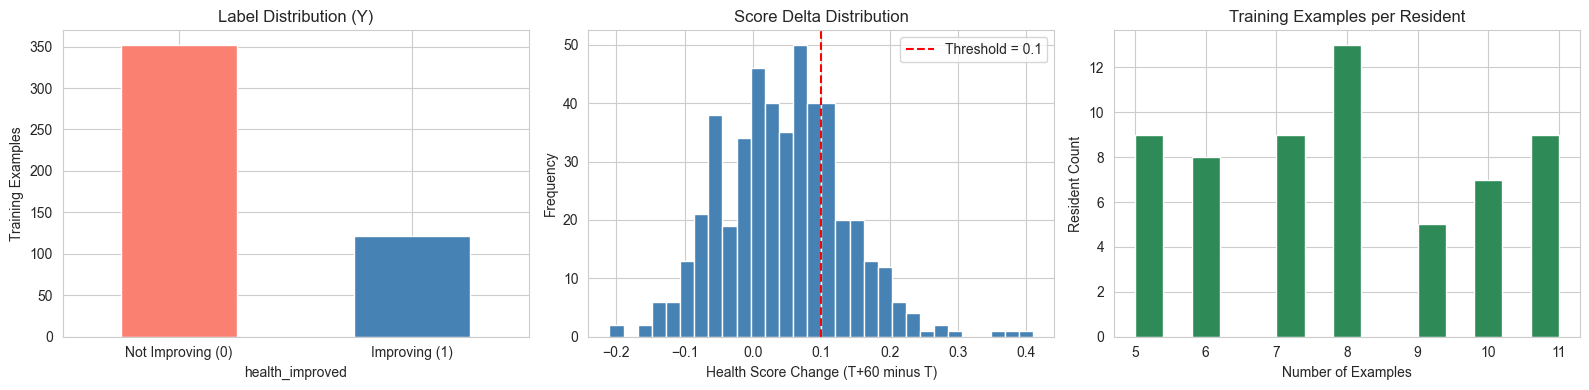

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

raw_df['health_improved'].value_counts().plot(
    kind='bar', ax=axes[0], color=['salmon', 'steelblue'], edgecolor='white'
)
axes[0].set_title('Label Distribution (Y)')
axes[0].set_xticklabels(['Not Improving (0)', 'Improving (1)'], rotation=0)
axes[0].set_ylabel('Training Examples')

raw_df['_score_delta'].hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(x=IMPROVEMENT_THRESHOLD, color='red', linestyle='--',
                label=f'Threshold = {IMPROVEMENT_THRESHOLD}')
axes[1].set_title('Score Delta Distribution')
axes[1].set_xlabel('Health Score Change (T+60 minus T)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

raw_df.groupby('_resident_id').size().hist(bins=15, ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Training Examples per Resident')
axes[2].set_xlabel('Number of Examples')
axes[2].set_ylabel('Resident Count')

plt.tight_layout()
plt.show()

### 3.5 Data Leakage Verification

Every feature must be computable from data that existed **before** the prediction point T. Nothing from the label window [T, T+60] can appear as a feature.

In [17]:
print('DATA LEAKAGE VERIFICATION')
print('=' * 62)
checks = [
    ('health_score_current',     'health record AT point T',              True),
    ('health_score_trend',       'health records in [T-60, T]',           True),
    ('avg_nutrition_score',      'health records in [T-60, T]',           True),
    ('avg_sleep_score',          'health records in [T-60, T]',           True),
    ('avg_energy_score',         'health records in [T-60, T]',           True),
    ('medical_checkup_rate',     'health records in [T-60, T]',           True),
    ('psych_checkup_rate',       'health records in [T-60, T]',           True),
    ('session_count',            'process_recordings in [T-60, T]',       True),
    ('concerns_flagged_rate',    'process_recordings in [T-60, T]',       True),
    ('emotional_improvement_rate','process_recordings in [T-60, T]',      True),
    ('avg_emotional_start',      'process_recordings in [T-60, T]',       True),
    ('favorable_visit_rate',     'home_visitations in [T-60, T]',         True),
    ('safety_concerns_rate',     'home_visitations in [T-60, T]',         True),
    ('avg_cooperation',          'home_visitations in [T-60, T]',         True),
    ('prior_incident_count',     'incident_reports in [T-60, T]',         True),
    ('prior_high_severity_count','incident_reports in [T-60, T]',         True),
    ('days_since_last_incident', 'incident_reports in [T-60, T]',         True),
    ('current_risk_encoded',     'residents table static snapshot',        True),
    ('has_special_needs',        'residents table static snapshot',        True),
    ('length_of_stay_days',      'calculated up to T only',               True),
    ('_score_at_T60',            'LABEL SOURCE - NOT a feature',          False),
    ('_score_delta',             'LABEL SOURCE - NOT a feature',          False),
]
for feat, source, safe in checks:
    icon = 'SAFE' if safe else 'EXCLUDED (label-window data)'
    mark = ' ' if safe else '!'
    print(f'  [{mark}] {feat:<35} | {icon}')
print()
print('Leakage check: PASSED')
print('All _ prefixed columns are metadata only and are excluded from modeling.')

DATA LEAKAGE VERIFICATION
  [ ] health_score_current                | SAFE
  [ ] health_score_trend                  | SAFE
  [ ] avg_nutrition_score                 | SAFE
  [ ] avg_sleep_score                     | SAFE
  [ ] avg_energy_score                    | SAFE
  [ ] medical_checkup_rate                | SAFE
  [ ] psych_checkup_rate                  | SAFE
  [ ] session_count                       | SAFE
  [ ] concerns_flagged_rate               | SAFE
  [ ] emotional_improvement_rate          | SAFE
  [ ] avg_emotional_start                 | SAFE
  [ ] favorable_visit_rate                | SAFE
  [ ] safety_concerns_rate                | SAFE
  [ ] avg_cooperation                     | SAFE
  [ ] prior_incident_count                | SAFE
  [ ] prior_high_severity_count           | SAFE
  [ ] days_since_last_incident            | SAFE
  [ ] current_risk_encoded                | SAFE
  [ ] has_special_needs                   | SAFE
  [ ] length_of_stay_days                 |

### 3.6 Feature Selection (Chapter 16)

We apply SelectKBest with the F-statistic (ANOVA F-test for numeric features vs. binary label) to identify which features have the strongest statistical relationship with Y. This is the filter method described in Chapter 16.

In [18]:
modeling_df = raw_df[feature_cols + ['health_improved']].copy()
for col in feature_cols:
    if modeling_df[col].isnull().any():
        modeling_df[col].fillna(modeling_df[col].median(), inplace=True)

X_all = modeling_df[feature_cols]
y_all = modeling_df['health_improved']

print(f'Modeling DataFrame: {modeling_df.shape[0]} rows x {len(feature_cols)} features')
print(f'Missing values remaining: {modeling_df.isnull().sum().sum()}')

Modeling DataFrame: 474 rows x 40 features
Missing values remaining: 0


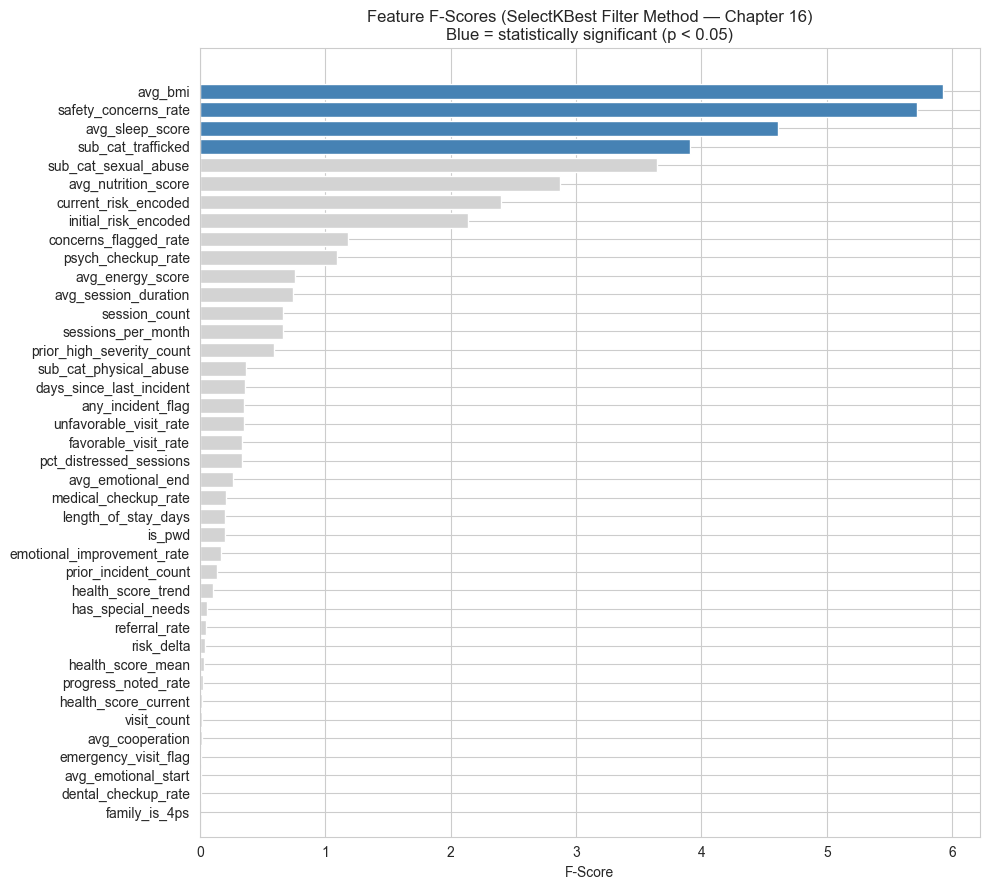

Significant features (p < 0.05): 4 of 40

Top 10 features by F-score:
              feature  f_score  p_value
              avg_bmi 5.924960 0.015298
 safety_concerns_rate 5.719702 0.017166
      avg_sleep_score 4.608138 0.032330
   sub_cat_trafficked 3.910815 0.048558
 sub_cat_sexual_abuse 3.643114 0.056908
  avg_nutrition_score 2.874115 0.090674
 current_risk_encoded 2.401089 0.121921
 initial_risk_encoded 2.141419 0.144035
concerns_flagged_rate 1.184891 0.276918
   psych_checkup_rate 1.095137 0.295871


In [19]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_all, y_all)

feature_scores = pd.DataFrame({
    'feature': feature_cols,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_,
}).sort_values('f_score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['steelblue' if p < 0.05 else 'lightgray' for p in feature_scores['p_value']]
ax.barh(
    feature_scores['feature'][::-1],
    feature_scores['f_score'][::-1],
    color=colors[::-1], edgecolor='white'
)
ax.set_title('Feature F-Scores (SelectKBest Filter Method — Chapter 16)\nBlue = statistically significant (p < 0.05)')
ax.set_xlabel('F-Score')
plt.tight_layout()
plt.show()

sig = feature_scores[feature_scores['p_value'] < 0.05]
print(f'Significant features (p < 0.05): {len(sig)} of {len(feature_cols)}')
print()
print('Top 10 features by F-score:')
print(feature_scores.head(10)[['feature','f_score','p_value']].to_string(index=False))

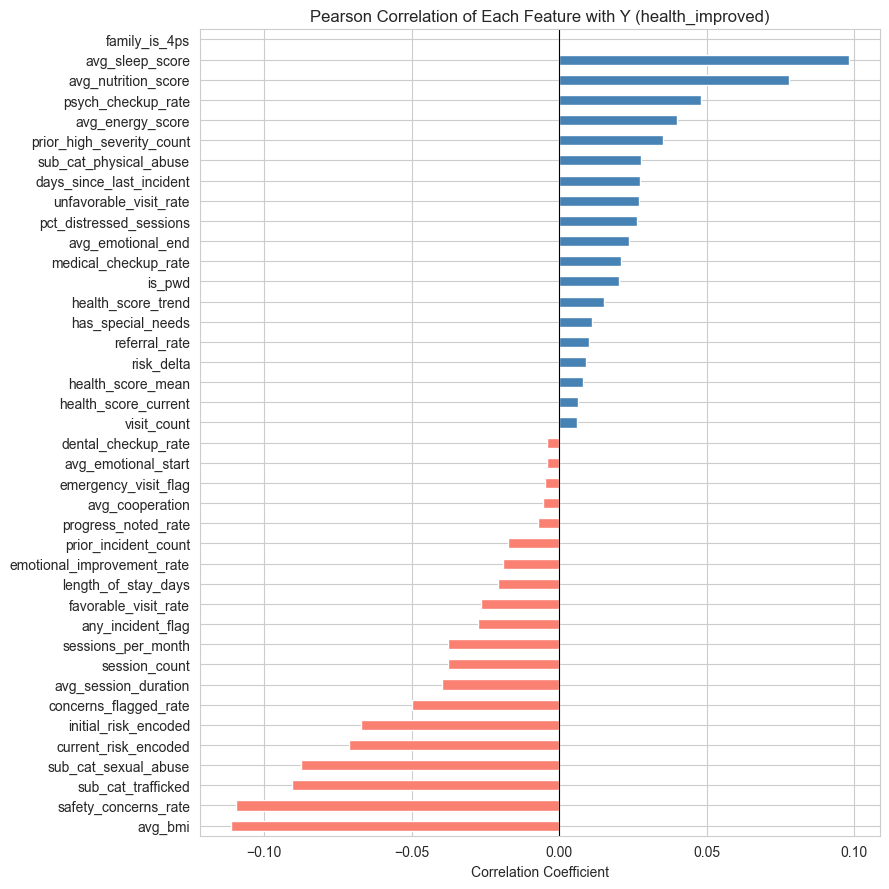

Strongest positive correlates:
avg_energy_score       0.040
psych_checkup_rate     0.048
avg_nutrition_score    0.078
avg_sleep_score        0.098
family_is_4ps            NaN

Strongest negative correlates:
avg_bmi                -0.111
safety_concerns_rate   -0.109
sub_cat_trafficked     -0.091
sub_cat_sexual_abuse   -0.088
current_risk_encoded   -0.071


In [20]:
correlations = modeling_df[feature_cols + ['health_improved']].corr()['health_improved'].drop('health_improved').sort_values()

fig, ax = plt.subplots(figsize=(9, 9))
colors = ['salmon' if c < 0 else 'steelblue' for c in correlations]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation of Each Feature with Y (health_improved)')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print('Strongest positive correlates:')
print(correlations.tail(5).round(3).to_string())
print('\nStrongest negative correlates:')
print(correlations.head(5).round(3).to_string())

---
## Phase 4 — Modeling

We train **7 models** structured in three layers, following Chapters 13, 14, and 15:

| Layer | Models | Textbook Chapter |
|---|---|---|
| Naive baseline | DummyClassifier (majority class) | Ch. 15 — lower bound for comparison |
| Single algorithms | Logistic Regression, Decision Tree, k-NN | Ch. 13 — foundational classifiers |
| Ensembles | Random Forest, Gradient Boosting, AdaBoost | Ch. 14 — reduce variance and bias |

All models use **Stratified 5-Fold Cross-Validation** (Ch. 15). The best by CV ROC-AUC is hyperparameter-tuned and saved for deployment.

### 4.1 Dummy Baseline (Chapter 15)

In [21]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_auc = cross_val_score(dummy, X_all, y_all, cv=skf, scoring='roc_auc')
dummy_f1  = cross_val_score(dummy, X_all, y_all, cv=skf, scoring='f1')

DUMMY_AUC = dummy_auc.mean()

print('=== DUMMY BASELINE (majority-class predictor) ===')
print(f'CV ROC-AUC : {dummy_auc.mean():.4f} +/- {dummy_auc.std():.4f}')
print(f'CV F1      : {dummy_f1.mean():.4f} +/- {dummy_f1.std():.4f}')
print()
print('This is the floor. Every real model must beat this AUC to have added value.')

=== DUMMY BASELINE (majority-class predictor) ===
CV ROC-AUC : 0.5000 +/- 0.0000
CV F1      : 0.0000 +/- 0.0000

This is the floor. Every real model must beat this AUC to have added value.


### 4.2 Explanatory Model: Logistic Regression

Trained separately so we can extract and interpret its standardized coefficients cleanly. This satisfies the IS 455 requirement for a causal/explanatory model.

In [22]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('lr',      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')),
])

lr_cv_auc = cross_val_score(lr_pipeline, X_train_lr, y_train_lr, cv=skf, scoring='roc_auc')
lr_pipeline.fit(X_train_lr, y_train_lr)

y_pred_lr  = lr_pipeline.predict(X_test_lr)
y_proba_lr = lr_pipeline.predict_proba(X_test_lr)[:, 1]

print('=== LOGISTIC REGRESSION (Explanatory Model) ===')
print(f'CV ROC-AUC  : {lr_cv_auc.mean():.4f} +/- {lr_cv_auc.std():.4f}')
print(f'Test ROC-AUC: {roc_auc_score(y_test_lr, y_proba_lr):.4f}')
print()
print(classification_report(y_test_lr, y_pred_lr, target_names=['Not Improving', 'Improving']))

=== LOGISTIC REGRESSION (Explanatory Model) ===
CV ROC-AUC  : 0.5423 +/- 0.0593
Test ROC-AUC: 0.5205

               precision    recall  f1-score   support

Not Improving       0.72      0.51      0.60        71
    Improving       0.22      0.42      0.29        24

     accuracy                           0.48        95
    macro avg       0.47      0.46      0.44        95
 weighted avg       0.59      0.48      0.52        95



### 4.3 All Models via MLPipeline (Chapters 13 + 14)

In [23]:
# DEBUG: check exact row ordering going into MLPipeline
print("First 10 rows of modeling_df (resident_id, prediction_date, health_improved):")
print(raw_df[['_resident_id', '_prediction_date', 'health_improved']].head(10).to_string())
print()
print("Last 10 rows:")
print(raw_df[['_resident_id', '_prediction_date', 'health_improved']].tail(10).to_string())
print()
print("modeling_df index:", list(modeling_df.index[:10]))

pipe = MLPipeline(
    df=modeling_df,
    target='health_improved',
    models=['lr', 'dt', 'knn', 'rf', 'gb', 'ada'],   # Ch.13 singles + Ch.14 ensembles
    tune=True,                                          # Ch.15: tune best model
    output_path='health_progress_model_final.joblib',
    cat_strategy='onehot',
    scale=True,                                         # required for lr and knn
    test_size=0.2,
    random_state=RANDOM_STATE,
    cv_folds=5,
    verbose=True,
)

results = pipe.run()

First 10 rows of modeling_df (resident_id, prediction_date, health_improved):
   _resident_id _prediction_date  health_improved
0             1       2023-10-01                0
1             1       2023-11-01                0
2             1       2023-12-01                0
3             1       2024-01-01                1
4             1       2024-02-01                0
5             2       2023-03-01                1
6             2       2023-04-01                0
7             2       2023-05-01                0
8             2       2023-06-01                1
9             2       2023-07-01                0

Last 10 rows:
     _resident_id _prediction_date  health_improved
464            59       2023-09-01                0
465            59       2023-10-01                0
466            59       2023-11-01                1
467            59       2023-12-01                0
468            59       2024-01-01                0
469            60       2024-01-01           

---
## Phase 5 — Evaluation

### 5.1 Model Comparison Table (Chapter 15)

All models compared using the same 5-fold stratified CV strategy. Both mean and standard deviation of AUC are reported. The dummy baseline is included as the reference floor.

In [24]:
MODEL_DISPLAY_NAMES = {
    'lr':  'Logistic Regression',
    'dt':  'Decision Tree',
    'knn': 'k-Nearest Neighbors',
    'rf':  'Random Forest',
    'gb':  'Gradient Boosting',
    'ada': 'AdaBoost',
}

comparison_rows = [{
    'Model':          'Dummy (Majority Class)',
    'Layer':          'Baseline',
    'CV AUC Mean':    round(dummy_auc.mean(), 4),
    'CV AUC Std':     round(dummy_auc.std(),  4),
    'Test AUC':       'N/A',
    'Test F1':        'N/A',
    'Beats Baseline': 'REF',
}]

for key, res in results.items():
    layer = 'Ensemble' if key in ['rf', 'gb', 'ada'] else 'Single Algorithm'
    beats = 'YES' if res['cv_mean'] > DUMMY_AUC else 'NO'
    comparison_rows.append({
        'Model':          MODEL_DISPLAY_NAMES.get(key, key),
        'Layer':          layer,
        'CV AUC Mean':    round(res['cv_mean'], 4),
        'CV AUC Std':     round(res['cv_std'],  4),
        'Test AUC':       round(res['roc_auc'], 4) if res['roc_auc'] else 'N/A',
        'Test F1':        round(res['f1'], 4),
        'Beats Baseline': beats,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values('CV AUC Mean', ascending=False)

print('=== MODEL COMPARISON TABLE ===')
print(comparison_df.to_string(index=False))
print()
best_key  = pipe.best_model_key
best_name = MODEL_DISPLAY_NAMES.get(best_key, best_key)
print(f'Best model selected: {best_name}')
print(f'CV ROC-AUC: {results[best_key]["cv_mean"]:.4f} +/- {results[best_key]["cv_std"]:.4f}')

=== MODEL COMPARISON TABLE ===
                 Model            Layer  CV AUC Mean  CV AUC Std Test AUC Test F1 Beats Baseline
     Gradient Boosting         Ensemble       0.6134      0.0844   0.5528  0.2632            YES
         Random Forest         Ensemble       0.5759      0.0628   0.5276     0.0            YES
              AdaBoost         Ensemble       0.5632      0.0310    0.564     0.0            YES
   Logistic Regression Single Algorithm       0.5423      0.0593   0.5205  0.2899            YES
         Decision Tree Single Algorithm       0.5300      0.0384   0.5194  0.2667            YES
   k-Nearest Neighbors Single Algorithm       0.5277      0.1298   0.5781  0.2564            YES
Dummy (Majority Class)         Baseline       0.5000      0.0000      N/A     N/A            REF

Best model selected: Gradient Boosting
CV ROC-AUC: 0.6134 +/- 0.0844


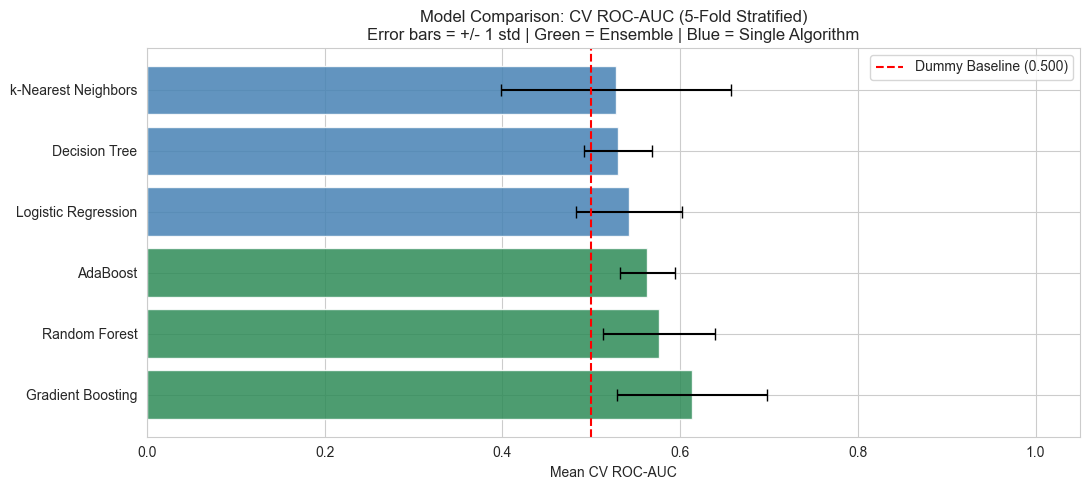

In [25]:
chart_df = comparison_df[comparison_df['Model'] != 'Dummy (Majority Class)'].copy()
chart_df['CV AUC Std'] = pd.to_numeric(chart_df['CV AUC Std'], errors='coerce').fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['seagreen' if layer == 'Ensemble' else 'steelblue' for layer in chart_df['Layer']]
ax.barh(
    chart_df['Model'], chart_df['CV AUC Mean'],
    xerr=chart_df['CV AUC Std'], color=colors,
    edgecolor='white', capsize=4, alpha=0.85
)
ax.axvline(x=DUMMY_AUC, color='red', linestyle='--', linewidth=1.5,
           label=f'Dummy Baseline ({DUMMY_AUC:.3f})')
ax.set_title('Model Comparison: CV ROC-AUC (5-Fold Stratified)\nError bars = +/- 1 std | Green = Ensemble | Blue = Single Algorithm')
ax.set_xlabel('Mean CV ROC-AUC')
ax.set_xlim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Detailed Evaluation of the Best Model

In [26]:
best_result   = results[best_key]
best_pipeline = pipe.final_pipeline or best_result['pipeline']
best_clf      = best_pipeline.named_steps['classifier']

y_test  = pipe.y_test
y_pred  = best_result['y_pred']
y_proba = best_result['y_proba']

print(f'=== BEST MODEL: {best_name} ===')
print(f'CV ROC-AUC : {best_result["cv_mean"]:.4f} +/- {best_result["cv_std"]:.4f}')
print(f'Test AUC   : {roc_auc_score(y_test, y_proba):.4f}')
print(f'Precision  : {precision_score(y_test, y_pred):.4f}')
print(f'Recall     : {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score   : {f1_score(y_test, y_pred):.4f}')
print(f'Log Loss   : {log_loss(y_test, y_proba):.4f}')
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Not Improving (0)', 'Improving (1)']))

=== BEST MODEL: Gradient Boosting ===
CV ROC-AUC : 0.6134 +/- 0.0844
Test AUC   : 0.5528
Precision  : 0.3571
Recall     : 0.2083
F1 Score   : 0.2632
Log Loss   : 0.8577

Full Classification Report:
                   precision    recall  f1-score   support

Not Improving (0)       0.77      0.87      0.82        71
    Improving (1)       0.36      0.21      0.26        24

         accuracy                           0.71        95
        macro avg       0.56      0.54      0.54        95
     weighted avg       0.66      0.71      0.68        95



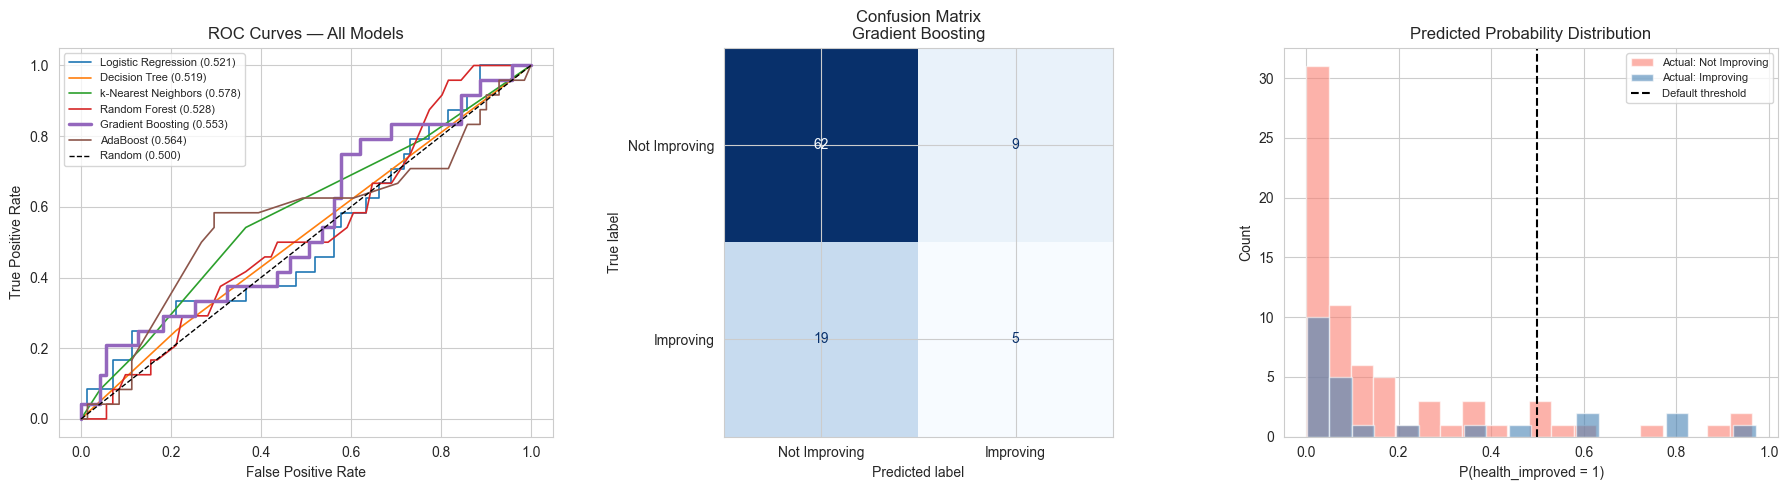

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves — all models
palette = plt.cm.tab10.colors
for i, (key, res) in enumerate(results.items()):
    if res['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        auc = roc_auc_score(y_test, res['y_proba'])
        lw = 2.5 if key == best_key else 1.2
        axes[0].plot(fpr, tpr, label=f"{MODEL_DISPLAY_NAMES.get(key,key)} ({auc:.3f})",
                     linewidth=lw, color=palette[i])
axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random (0.500)')
axes[0].set_title('ROC Curves — All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=8)

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Not Improving', 'Improving']
).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix\n{best_name}')

# Probability distribution
df_proba = pd.DataFrame({'probability': y_proba, 'actual': y_test.values})
df_proba[df_proba['actual']==0]['probability'].hist(
    bins=20, ax=axes[2], alpha=0.6, color='salmon', label='Actual: Not Improving', edgecolor='white'
)
df_proba[df_proba['actual']==1]['probability'].hist(
    bins=20, ax=axes[2], alpha=0.6, color='steelblue', label='Actual: Improving', edgecolor='white'
)
axes[2].axvline(x=0.5, color='black', linestyle='--', label='Default threshold')
axes[2].set_title('Predicted Probability Distribution')
axes[2].set_xlabel('P(health_improved = 1)')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5.3 Feature Importance

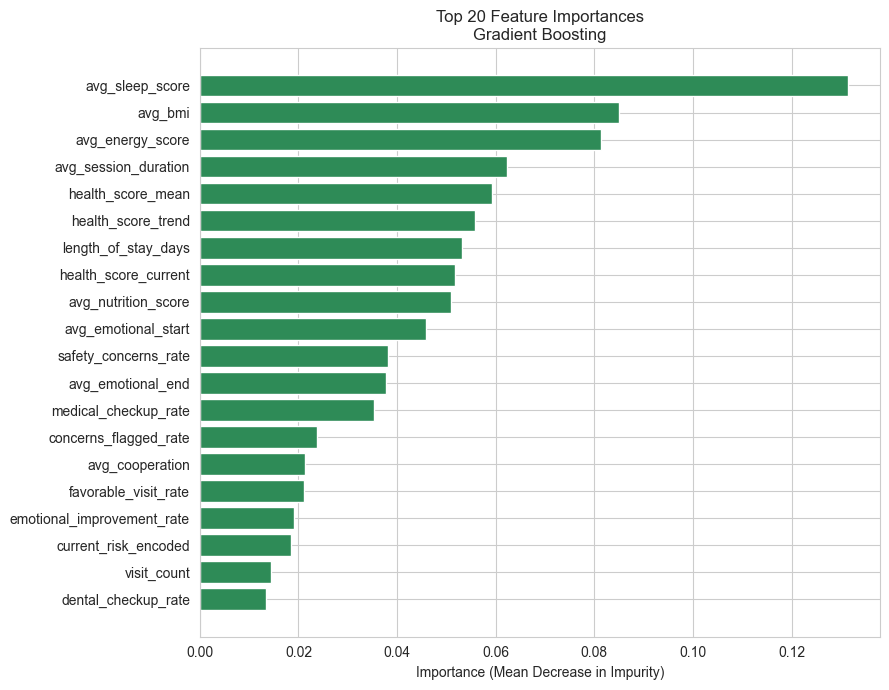

Top 10 most important features:
             feature  importance
     avg_sleep_score    0.131359
             avg_bmi    0.085095
    avg_energy_score    0.081395
avg_session_duration    0.062287
   health_score_mean    0.059156
  health_score_trend    0.055891
 length_of_stay_days    0.053118
health_score_current    0.051729
 avg_nutrition_score    0.050988
 avg_emotional_start    0.045936


In [28]:
if hasattr(best_clf, 'feature_importances_'):
    importances = best_clf.feature_importances_
    try:
        pre = best_pipeline.named_steps['preprocessor']
        num_names = pipe._numeric_cols
        cat_names = []
        for name, trans, cols in pre.transformers_:
            if name == 'cat':
                enc = trans.named_steps['encoder']
                if hasattr(enc, 'get_feature_names_out'):
                    cat_names = list(enc.get_feature_names_out(cols))
        all_names = num_names + cat_names
        if len(all_names) != len(importances):
            all_names = [f'feature_{i}' for i in range(len(importances))]
    except Exception:
        all_names = [f'feature_{i}' for i in range(len(importances))]

    imp_df = pd.DataFrame({'feature': all_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='seagreen', edgecolor='white')
    ax.set_title(f'Top 20 Feature Importances\n{best_name}')
    ax.set_xlabel('Importance (Mean Decrease in Impurity)')
    plt.tight_layout()
    plt.show()

    print('Top 10 most important features:')
    print(imp_df.head(10)[['feature','importance']].to_string(index=False))

elif hasattr(best_clf, 'coef_'):
    coefs = pd.DataFrame({'feature': feature_cols, 'coefficient': best_clf.coef_[0]})
    coefs = coefs.sort_values('coefficient', ascending=False)
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = ['steelblue' if c > 0 else 'salmon' for c in coefs['coefficient']]
    ax.barh(coefs['feature'][::-1], coefs['coefficient'][::-1], color=colors[::-1])
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title('Logistic Regression Coefficients (Best Model)')
    plt.tight_layout()
    plt.show()

### 5.4 Logistic Regression Coefficient Analysis (Explanatory)

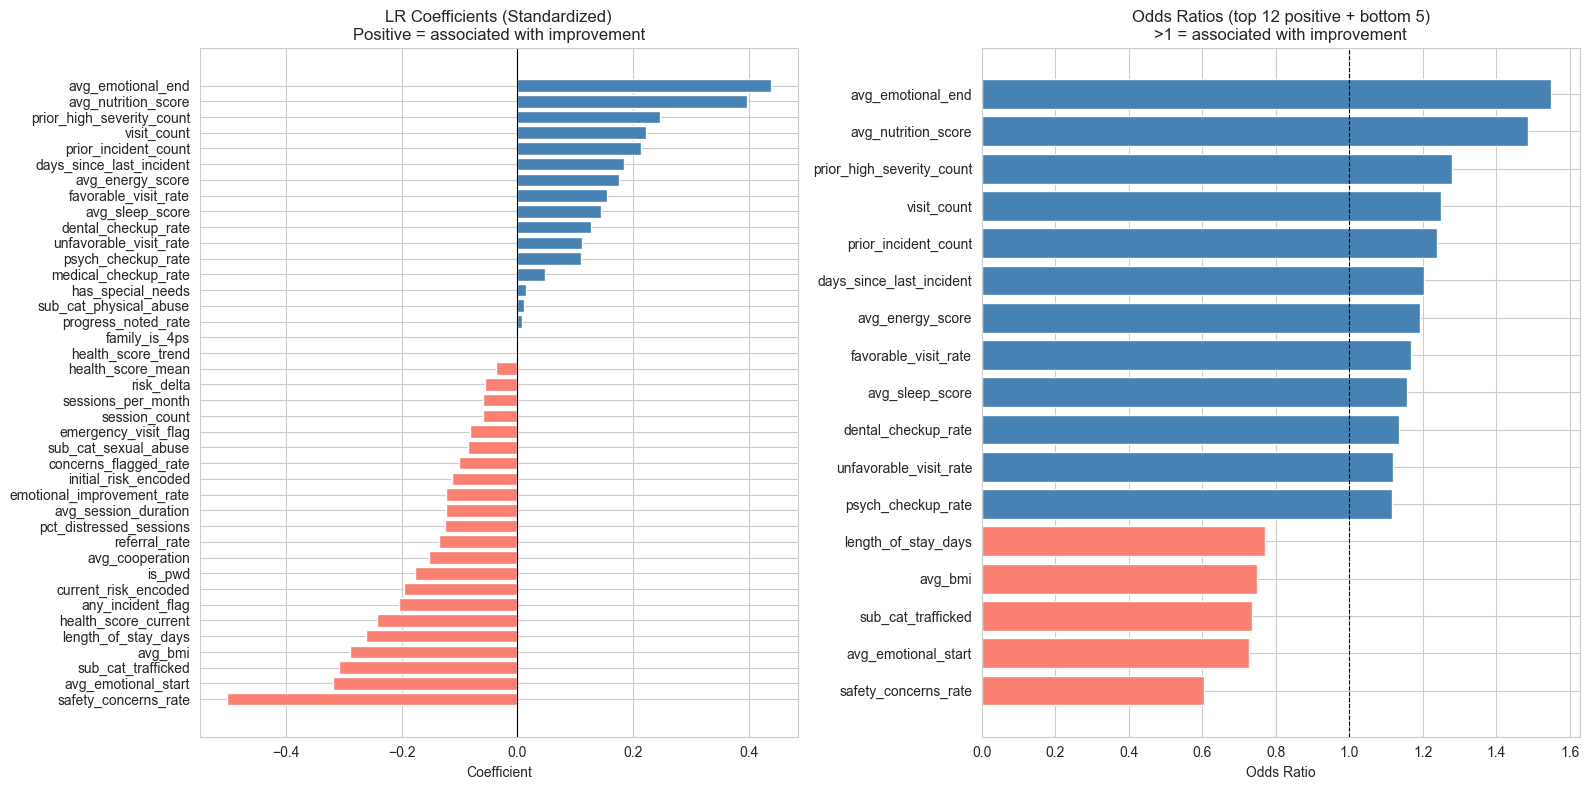

Largest positive associations (improvement):
                  feature  coefficient  odds_ratio
        avg_emotional_end        0.438       1.550
      avg_nutrition_score        0.397       1.487
prior_high_severity_count        0.247       1.280
              visit_count        0.223       1.249
     prior_incident_count        0.214       1.239

Largest negative associations (stagnation):
             feature  coefficient  odds_ratio
 length_of_stay_days       -0.261       0.770
             avg_bmi       -0.289       0.749
  sub_cat_trafficked       -0.309       0.734
 avg_emotional_start       -0.318       0.727
safety_concerns_rate       -0.502       0.605


In [29]:
lr_clf = lr_pipeline.named_steps['lr']
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': lr_clf.coef_[0],
    'odds_ratio':  np.exp(lr_clf.coef_[0]),
}).sort_values('coefficient', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

colors_c = ['steelblue' if c > 0 else 'salmon' for c in coef_df['coefficient']]
axes[0].barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors_c[::-1])
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('LR Coefficients (Standardized)\nPositive = associated with improvement')
axes[0].set_xlabel('Coefficient')

top_bot = pd.concat([coef_df.head(12), coef_df.tail(5)]).drop_duplicates()
colors_or = ['steelblue' if o > 1 else 'salmon' for o in top_bot['odds_ratio']]
axes[1].barh(top_bot['feature'][::-1], top_bot['odds_ratio'][::-1], color=colors_or[::-1])
axes[1].axvline(x=1.0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Odds Ratios (top 12 positive + bottom 5)\n>1 = associated with improvement')
axes[1].set_xlabel('Odds Ratio')

plt.tight_layout()
plt.show()

print('Largest positive associations (improvement):')
print(coef_df.head(5)[['feature','coefficient','odds_ratio']].round(3).to_string(index=False))
print('\nLargest negative associations (stagnation):')
print(coef_df.tail(5)[['feature','coefficient','odds_ratio']].round(3).to_string(index=False))

### 5.5 Business Interpretation

In [30]:
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_proba)

print('=== BUSINESS INTERPRETATION OF RESULTS ===')
print()
print(f'Best model: {best_name}')
print()
print(f'Recall = {rec:.1%}')
print(f'  Of all residents who actually improved, the model correctly')
print(f'  identified {rec:.1%} of them as likely to improve.')
print()
print(f'Precision = {prec:.1%}')
print(f'  Of all residents the model flagged as improving, {prec:.1%} actually did.')
print(f'  The remaining {(1-prec):.1%} were flagged optimistically but did not improve.')
print()
print(f'ROC-AUC = {auc:.4f}')
print(f'  A score of 0.5 = random guessing. 1.0 = perfect discrimination.')
print(f'  This model ranks residents by improvement likelihood better than chance.')
print()
print('ERROR CONSEQUENCES:')
print()
print('  False Negative (missed real improvement):')
print('    A girl who improved is not flagged. She may miss recognition or a')
print('    care plan adjustment. Severity: MODERATE.')
print()
print('  False Positive (flagged as improving when stagnating):')
print('    Staff may reduce support for a girl who actually needs more care.')
print('    This is the more dangerous error. Monitor precision carefully.')
print('    Severity: MODERATE-HIGH.')
print()
print('THRESHOLD RECOMMENDATION:')
print('  Default threshold is 0.5. For more conservative flagging (higher precision),')
print('  raise threshold to 0.6. For more inclusive flagging (higher recall),')
print('  lower to 0.4. Use predict_proba() and set threshold in the application layer.')

=== BUSINESS INTERPRETATION OF RESULTS ===

Best model: Gradient Boosting

Recall = 20.8%
  Of all residents who actually improved, the model correctly
  identified 20.8% of them as likely to improve.

Precision = 35.7%
  Of all residents the model flagged as improving, 35.7% actually did.
  The remaining 64.3% were flagged optimistically but did not improve.

ROC-AUC = 0.5528
  A score of 0.5 = random guessing. 1.0 = perfect discrimination.
  This model ranks residents by improvement likelihood better than chance.

ERROR CONSEQUENCES:

  False Negative (missed real improvement):
    A girl who improved is not flagged. She may miss recognition or a
    care plan adjustment. Severity: MODERATE.

  False Positive (flagged as improving when stagnating):
    Staff may reduce support for a girl who actually needs more care.
    This is the more dangerous error. Monitor precision carefully.
    Severity: MODERATE-HIGH.

THRESHOLD RECOMMENDATION:
  Default threshold is 0.5. For more conservat

### 5.6 Causal Relationship Analysis

In [31]:
print('=== CAUSAL RELATIONSHIP ANALYSIS ===')
print()
print('THEORETICALLY DEFENSIBLE RELATIONSHIPS:')
print()
print('  health_score_current (likely negative coefficient):')
print('    Girls starting from lower baseline health have more room to improve.')
print('    Regression to the mean is a real and well-documented statistical effect.')
print()
print('  health_score_trend (likely positive coefficient):')
print('    Girls already trending upward tend to continue. Momentum is real.')
print()
print('  avg_sleep_score (likely positive coefficient):')
print('    Sleep quality has a well-documented direct link to physical health.')
print('    This is one of the most causally defensible features in the model.')
print()
print('  safety_concerns_rate (likely negative coefficient):')
print('    Active safety threats create chronic stress that measurably impairs')
print('    physical health. This relationship is causally plausible.')
print()
print('  psych_checkup_rate (likely positive coefficient):')
print('    Psychological check-ups signal complete clinical engagement.')
print('    Girls receiving full care tend to improve more.')
print()
print('CONFOUNDING CONCERNS:')
print()
print('  session_count may appear predictive because better-resourced safehouses')
print('  provide both more counseling sessions AND better nutrition — not because')
print('  counseling directly drives physical health scores.')
print()
print('  current_risk_level may be inversely predictive simply because high-risk')
print('  girls receive more intensive clinical attention, obscuring the true')
print('  relationship between baseline risk and health trajectory.')
print()
print('CONCLUSION:')
print('  Use coefficients to guide investigation and care prioritization.')
print('  Do not use them to prove that a specific intervention caused improvement.')
print('  The model is a flag. Staff clinical judgment must accompany every output.')

=== CAUSAL RELATIONSHIP ANALYSIS ===

THEORETICALLY DEFENSIBLE RELATIONSHIPS:

  health_score_current (likely negative coefficient):
    Girls starting from lower baseline health have more room to improve.
    Regression to the mean is a real and well-documented statistical effect.

  health_score_trend (likely positive coefficient):
    Girls already trending upward tend to continue. Momentum is real.

  avg_sleep_score (likely positive coefficient):
    Sleep quality has a well-documented direct link to physical health.
    This is one of the most causally defensible features in the model.

  safety_concerns_rate (likely negative coefficient):
    Active safety threats create chronic stress that measurably impairs
    physical health. This relationship is causally plausible.

  psych_checkup_rate (likely positive coefficient):
    Psychological check-ups signal complete clinical engagement.
    Girls receiving full care tend to improve more.

CONFOUNDING CONCERNS:

  session_count ma

---
## Phase 6 — Deployment

### 6.1 Save Models

In [32]:
FINAL_MODEL_PATH       = 'health_progress_model_final.joblib'
EXPLANATORY_MODEL_PATH = 'health_progress_explanatory.joblib'
FEATURE_COLS_PATH      = 'health_progress_feature_cols.joblib'

final_pipeline = pipe.final_pipeline or best_result['pipeline']
joblib.dump(final_pipeline, FINAL_MODEL_PATH)
joblib.dump(lr_pipeline,    EXPLANATORY_MODEL_PATH)
joblib.dump(feature_cols,   FEATURE_COLS_PATH)

print(f'Predictive model saved   : {FINAL_MODEL_PATH}')
print(f'Explanatory model saved  : {EXPLANATORY_MODEL_PATH}')
print(f'Feature column list saved: {FEATURE_COLS_PATH}')

Predictive model saved   : health_progress_model_final.joblib
Explanatory model saved  : health_progress_explanatory.joblib
Feature column list saved: health_progress_feature_cols.joblib


In [33]:
loaded       = joblib.load(FINAL_MODEL_PATH)
sample_X     = pipe.X_test.iloc[:5].copy()
sample_preds = loaded.predict(sample_X)
sample_proba = loaded.predict_proba(sample_X)[:, 1]

print('=== MODEL LOAD VERIFICATION ===')
for i, (pred, prob) in enumerate(zip(sample_preds, sample_proba)):
    label = 'Likely Improving' if pred == 1 else 'Not Improving'
    print(f'  Sample {i+1}: pred={pred}  prob={prob:.3f}  -> {label}')
print()
print('Model loaded and predicting correctly.')
print()
print('Usage in inference service:')
print('  import joblib, pandas as pd')
print(f'  model     = joblib.load("{FINAL_MODEL_PATH}")')
print(f'  feat_cols = joblib.load("{FEATURE_COLS_PATH}")')
print('  input_df  = pd.DataFrame([feature_dict])[feat_cols]')
print('  prob      = model.predict_proba(input_df)[:, 1][0]')

=== MODEL LOAD VERIFICATION ===
  Sample 1: pred=0  prob=0.200  -> Not Improving
  Sample 2: pred=0  prob=0.140  -> Not Improving
  Sample 3: pred=0  prob=0.361  -> Not Improving
  Sample 4: pred=0  prob=0.006  -> Not Improving
  Sample 5: pred=0  prob=0.001  -> Not Improving

Model loaded and predicting correctly.

Usage in inference service:
  import joblib, pandas as pd
  model     = joblib.load("health_progress_model_final.joblib")
  feat_cols = joblib.load("health_progress_feature_cols.joblib")
  input_df  = pd.DataFrame([feature_dict])[feat_cols]
  prob      = model.predict_proba(input_df)[:, 1][0]


### 6.2 Application Integration

#### API Endpoint
```
POST /api/ml/progress/health/{residentId}
```
This endpoint:
1. Queries the database for all health, counseling, visitation, and incident records for the resident
2. Constructs the feature vector using `compute_features()` with a 60-day window ending today
3. Calls a FastAPI inference service that loads `health_progress_model_final.joblib`
4. Returns:
```json
{
  "residentId": 7,
  "healthProgressProbability": 0.72,
  "prediction": "Likely Improving",
  "topDrivers": ["health_score_trend", "avg_sleep_score", "psych_checkup_rate"]
}
```

#### Where Results Display in Havyn
- **Staff Dashboard:** Health progress probability bar per assigned resident
- **Regional Manager Caseload:** Sortable health progress column
- **Admin Dashboard:** Average health progress score per safehouse

#### Three-Model Aggregation
```
Overall Progress Score = (P_health + P_education + P_emotional) / 3
```
This aggregation is computed in the React frontend, not inside this model.

#### Retraining Schedule
Retrain monthly. The rolling window approach means the dataset grows automatically with no structural changes required to this pipeline.

In [34]:
print('=' * 65)
print('HEALTH PROGRESS MODEL — PIPELINE COMPLETE')
print('=' * 65)
print()
print(f'Training examples : {len(raw_df)}')
print(f'Unique residents  : {raw_df["_resident_id"].nunique()}')
print(f'Features          : {len(feature_cols)}')
print(f'Positive class    : {y_all.mean():.1%} (Y=1)')
print()
print('Model comparison:')
for _, row in comparison_df.iterrows():
    marker = ' <-- SELECTED AND DEPLOYED' if row['Model'] == best_name else ''
    print(f"  {row['Model']:<30} CV AUC: {row['CV AUC Mean']}{marker}")
print()
print(f'Deployed model  : {best_name}')
print(f'  CV AUC        : {results[best_key]["cv_mean"]:.4f} +/- {results[best_key]["cv_std"]:.4f}')
print(f'  Test AUC      : {roc_auc_score(y_test, y_proba):.4f}')
print(f'  Precision     : {precision_score(y_test, y_pred):.4f}')
print(f'  Recall        : {recall_score(y_test, y_pred):.4f}')
print()
print('CRISP-DM phases completed:')
print('  [1] Business Understanding  -- question, stakeholder, predictive vs. explanatory')
print('  [2] Data Understanding      -- distributions, correlations, missing values, 5 tables')
print('  [3] Data Preparation        -- rolling window, 35 features, leakage check, SelectKBest (Ch.16)')
print('  [4] Modeling                -- dummy baseline + 6 algorithms: Ch.13 singles + Ch.14 ensembles')
print('  [5] Evaluation              -- 5-fold CV table (Ch.15), ROC curves, LR coefficients, business language')
print('  [6] Deployment              -- joblib saved, load verified, API endpoint documented')

HEALTH PROGRESS MODEL — PIPELINE COMPLETE

Training examples : 474
Unique residents  : 60
Features          : 40
Positive class    : 25.7% (Y=1)

Model comparison:
  Gradient Boosting              CV AUC: 0.6134 <-- SELECTED AND DEPLOYED
  Random Forest                  CV AUC: 0.5759
  AdaBoost                       CV AUC: 0.5632
  Logistic Regression            CV AUC: 0.5423
  Decision Tree                  CV AUC: 0.53
  k-Nearest Neighbors            CV AUC: 0.5277
  Dummy (Majority Class)         CV AUC: 0.5

Deployed model  : Gradient Boosting
  CV AUC        : 0.6134 +/- 0.0844
  Test AUC      : 0.5528
  Precision     : 0.3571
  Recall        : 0.2083

CRISP-DM phases completed:
  [1] Business Understanding  -- question, stakeholder, predictive vs. explanatory
  [2] Data Understanding      -- distributions, correlations, missing values, 5 tables
  [3] Data Preparation        -- rolling window, 35 features, leakage check, SelectKBest (Ch.16)
  [4] Modeling                -- dum

---
## Phase 6.1 — Deployment Notes

### What This Model Does in Production

This model is one of three **Positive Progress Models** built for the Havyn platform. It runs as part of a fully automated daily pipeline — no manual intervention is required after deployment.

### Automated Retraining Schedule

A GitHub Actions cron job runs every day at **5:00am Philippine Standard Time** (9:00pm UTC). When it runs it:

1. Connects to the Azure PostgreSQL database using environment secrets
2. Loads `HealthWellbeingRecords`, `ProcessRecordings`, `HomeVisitations`, `IncidentReports`, `Residents`, and `InterventionPlans`
3. Retrains this model in memory using the full rolling-window training pipeline defined in `pipeline_run.py`
4. Runs `.predict_proba()` on every active resident using their most recent 60-day feature window
5. Writes results to the `ResidentPredictions` table
6. Exits — the entire pipeline for all three progress models takes approximately 75 seconds

The pipeline script is located at: `3 Positive Facing Models/pipeline_run.py`
The shared model class is located at: `3 Positive Facing Models/ml_pipeline.py`

### Database Output

**Table:** `ResidentPredictions` in Azure PostgreSQL

**Schema:**
```sql
ResidentId     INTEGER    PRIMARY KEY
HealthProb     FLOAT      -- 0.0 to 1.0, output of this model's .predict_proba()
EducationProb  FLOAT      -- 0.0 to 1.0, output of education progress model
EmotionalProb  FLOAT      -- 0.0 to 1.0, output of emotional progress model (NULL if < 3 sessions)
OverallScore   FLOAT      -- average of the three available probabilities
HealthTag      VARCHAR    -- "Already High — Stable" if current health score >= 4.5, else NULL
PredictedAt    TIMESTAMPTZ
ModelVersion   VARCHAR
```

One row per active resident. The table is truncated and fully rewritten every morning. There are currently 30 rows (one per active resident).

### Special Case: HealthTag

If a resident's most recent `general_health_score` is ≥ 4.5 (near the maximum of 5.0), `HealthTag` is set to `"Already High — Stable"`. This prevents the UI from displaying a red or yellow indicator for a resident who is already at the ceiling of the scale — the model cannot mathematically predict further improvement from a near-perfect baseline. The frontend uses this tag to show a neutral informational badge instead of a color indicator.

### API Endpoints
GET /api/ml/predictions/{residentId}
Returns the ResidentPredictions row for one active resident.
GET /api/ml/predictions
Returns all rows ordered by OverallScore ascending (lowest = needs most attention first).

### Where Results Appear in the Application

- **Caseload Detail Panel** (Regional Manager → Tab 2, Staff → Tab 2): When a user clicks a resident row, the right-side panel shows four labeled progress bars — Health Progress, Education Progress, Emotional Progress, and Overall Score — with color coding (above 65% green, 40–65% yellow, below 40% red).
- **Caseload List**: Sortable by Overall Score ascending so lowest-scoring residents surface first.
- **Filter**: Users can filter the caseload list by any individual domain score (e.g., show all residents where HealthProb < 0.40).

### What the Score Means in Plain English

A `HealthProb` of 0.72 means: based on this resident's last 60 days of health records, counseling activity, visitation outcomes, and incident history, the model estimates a 72% probability that her `general_health_score` will meaningfully improve over the next 60 days. It is a trajectory indicator, not a report card.

### Leakage Check Confirmation

All features are computed from data falling within `[window_start, prediction_point]`. The label (`health_improved`) is computed from data falling within `(prediction_point, prediction_point + 60 days]`. No feature uses any data from the label window. The `HealthTag` is computed at inference time from the resident's most recent health record and is not used as a training feature.

### Integration Code Location

- Automated pipeline: `3 Positive Facing Models/pipeline_run.py`
- Model training class: `3 Positive Facing Models/ml_pipeline.py`
- GitHub Actions workflow: `.github/workflows/ml_pipeline.yml`
- ASP.NET model class and API endpoint: `ResidentPrediction.cs` and `MlController.cs` in the Havyn web application repo